In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# df = pd.read_csv(
#     "/Users/linda/Desktop/WNBA/af22840c-69dd-4400-8d01-502370d15c7e"
# )

# # Convert attendance to numbers
# df["Attendance"] = pd.to_numeric(df["Attendance"], errors="coerce")

# # Add attendance for all games in each year
# yearly_attendance = (
#     df.groupby("Year")["Attendance"]
#       .sum()
#       .reset_index()
# )

# plt.figure(figsize=(12, 6))

# plt.plot(
#     yearly_attendance["Year"],
#     yearly_attendance["Attendance"],
#     marker="o"
# )

# plt.title("Total WNBA Attendance by Year")
# plt.xlabel("Year")
# plt.ylabel("Total Attendance")
# plt.xticks(yearly_attendance["Year"], rotation=45)
# plt.grid(True)
# plt.tight_layout()

# plt.show()

In [33]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import re

# # Change this path if your CSV is stored somewhere else
# file_path = "/Users/linda/Downloads/insidehoops_nba_attendance.csv"

# df = pd.read_csv(file_path)

# # Keep regular-season TOTALS rows
# # Home attendance represents total league attendance without double-counting games
# totals = df[
#     (df["category"] == "Regular Season")
#     & (df["team"].str.contains("TOTAL", case=False, na=False))
# ].copy()

# def get_season(title):
#     match = re.search(r"(20\d{2})-(20\d{2}|\d{2})", str(title))

#     if match is None:
#         return None

#     start_year = int(match.group(1))
#     end_text = match.group(2)

#     if len(end_text) == 4:
#         end_year = int(end_text)
#     else:
#         end_year = 2000 + int(end_text)

#     return f"{start_year}-{str(end_year)[-2:]}"

# totals["season"] = totals["source_table"].apply(get_season)

# annual_attendance = totals[
#     ["season", "home_games", "home_attendance"]
# ].copy()

# annual_attendance = annual_attendance.rename(
#     columns={
#         "home_games": "total_games",
#         "home_attendance": "total_attendance"
#     }
# )

# annual_attendance = (
#     annual_attendance
#     .dropna(subset=["season"])
#     .sort_values("season")
#     .reset_index(drop=True)
# )

# display(annual_attendance)

# plt.figure(figsize=(12, 6))

# plt.plot(
#     annual_attendance["season"],
#     annual_attendance["total_attendance"],
#     marker="o",
#     linewidth=2
# )

# plt.title("Total NBA Regular-Season Attendance by Season")
# plt.xlabel("Season")
# plt.ylabel("Total Attendance")

# plt.xticks(rotation=45)
# plt.ticklabel_format(style="plain", axis="y")
# plt.grid(axis="y", alpha=0.3)

# plt.tight_layout()
# plt.show()

In [34]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import re

# # -----------------------------
# # 1. LOAD WNBA DATA
# # -----------------------------

# wnba_file = "/Users/linda/Desktop/wnba/af22840c-69dd-4400-8d01-502370d15c7e"

# wnba = pd.read_csv(wnba_file)

# # Convert columns to numbers
# wnba["Year"] = pd.to_numeric(wnba["Year"], errors="coerce")
# wnba["Attendance"] = pd.to_numeric(
#     wnba["Attendance"].astype(str).str.replace(",", ""),
#     errors="coerce"
# )

# # Add attendance for every WNBA game in each year
# wnba_yearly = (
#     wnba.groupby("Year", as_index=False)["Attendance"]
#         .sum()
#         .rename(columns={"Attendance": "WNBA Attendance"})
# )

# # -----------------------------
# # 2. LOAD NBA DATA
# # -----------------------------

# nba_file = "/Users/linda/Desktop/wnba/insidehoops_nba_attendance.csv"

# nba = pd.read_csv(nba_file)

# # Keep only regular-season league totals
# nba_totals = nba[
#     (nba["category"] == "Regular Season")
#     & (nba["team"].str.contains("TOTAL", case=False, na=False))
# ].copy()

# # Extract the ending year from each NBA season
# # Example: 2023-24 becomes 2024
# def get_nba_year(title):
#     match = re.search(r"(20\d{2})-(20\d{2}|\d{2})", str(title))

#     if match is None:
#         return None

#     ending_year = match.group(2)

#     if len(ending_year) == 2:
#         return 2000 + int(ending_year)

#     return int(ending_year)

# nba_totals["Year"] = nba_totals["source_table"].apply(get_nba_year)

# nba_totals["home_attendance"] = pd.to_numeric(
#     nba_totals["home_attendance"]
#         .astype(str)
#         .str.replace(",", ""),
#     errors="coerce"
# )

# nba_yearly = (
#     nba_totals[["Year", "home_attendance"]]
#     .rename(columns={"home_attendance": "NBA Attendance"})
#     .dropna()
#     .sort_values("Year")
# )

# # -----------------------------
# # 3. COMBINE BOTH DATASETS
# # -----------------------------

# combined = pd.merge(
#     nba_yearly,
#     wnba_yearly,
#     on="Year",
#     how="outer"
# ).sort_values("Year")

# display(combined)

# # -----------------------------
# # 4. CREATE COMBINED LINE CHART
# # -----------------------------

# plt.figure(figsize=(14, 7))

# plt.plot(
#     combined["Year"],
#     combined["NBA Attendance"],
#     marker="o",
#     linewidth=2,
#     label="NBA"
# )

# plt.plot(
#     combined["Year"],
#     combined["WNBA Attendance"],
#     marker="o",
#     linewidth=2,
#     label="WNBA"
# )

# plt.title("Total NBA and WNBA Attendance by Year")
# plt.xlabel("Year")
# plt.ylabel("Total Attendance")

# plt.xticks(combined["Year"].dropna().astype(int), rotation=45)
# plt.ticklabel_format(style="plain", axis="y")

# plt.grid(axis="y", alpha=0.3)
# plt.legend()
# plt.tight_layout()

# plt.show()

In [35]:
# # Keep years where both NBA and WNBA have attendance data
# percentage_data = combined.dropna(
#     subset=["NBA Attendance", "WNBA Attendance"]
# ).copy()

# # Make the first shared year equal to 100%
# percentage_data["NBA Attendance Index"] = (
#     percentage_data["NBA Attendance"]
#     / percentage_data["NBA Attendance"].iloc[0]
# ) * 100

# percentage_data["WNBA Attendance Index"] = (
#     percentage_data["WNBA Attendance"]
#     / percentage_data["WNBA Attendance"].iloc[0]
# ) * 100

# # Display the percentage table
# display(
#     percentage_data[
#         ["Year", "NBA Attendance Index", "WNBA Attendance Index"]
#     ].round(1)
# )

# # Create the percentage-based line chart
# plt.figure(figsize=(14, 7))

# plt.plot(
#     percentage_data["Year"],
#     percentage_data["NBA Attendance Index"],
#     marker="o",
#     linewidth=2,
#     label="NBA"
# )

# plt.plot(
#     percentage_data["Year"],
#     percentage_data["WNBA Attendance Index"],
#     marker="o",
#     linewidth=2,
#     label="WNBA"
# )

# # Reference line showing the starting level
# plt.axhline(
#     y=100,
#     linestyle="--",
#     linewidth=1,
#     label="Starting year = 100%"
# )

# plt.title("NBA vs. WNBA Attendance Growth by Year")
# plt.xlabel("Year")
# plt.ylabel("Attendance Index (%)")

# plt.xticks(
#     percentage_data["Year"].astype(int),
#     rotation=45
# )

# plt.grid(axis="y", alpha=0.3)
# plt.legend()
# plt.tight_layout()

# plt.show()

In [36]:
# # -----------------------------
# # 4. CREATE ACCESSIBLE LINE CHART
# # -----------------------------

# # Keep only rows from 2014 onward
# combined = combined[combined["Year"] >= 2014].copy()

# plt.figure(figsize=(14, 7))

# # NBA: solid line with circle markers
# plt.plot(
#     combined["Year"],
#     combined["NBA Attendance"],
#     marker="o",
#     linestyle="-",
#     linewidth=2.5,
#     label="NBA"
# )

# # WNBA: dashed line with square markers
# plt.plot(
#     combined["Year"],
#     combined["WNBA Attendance"],
#     marker="s",
#     linestyle="--",
#     linewidth=2.5,
#     label="WNBA"
# )

# # Find the last available NBA value
# nba_last = combined.dropna(subset=["NBA Attendance"]).iloc[-1]

# # Find the last available WNBA value
# wnba_last = combined.dropna(subset=["WNBA Attendance"]).iloc[-1]

# # Add labels beside the final points
# plt.text(
#     nba_last["Year"] + 0.2,
#     nba_last["NBA Attendance"],
#     "NBA",
#     fontsize=12,
#     fontweight="bold",
#     va="center"
# )

# plt.text(
#     wnba_last["Year"] + 0.2,
#     wnba_last["WNBA Attendance"],
#     "WNBA",
#     fontsize=12,
#     fontweight="bold",
#     va="center"
# )

# plt.title("Total NBA and WNBA Attendance by Year, 2014–Present")
# plt.xlabel("Year")
# plt.ylabel("Total Attendance")

# plt.xticks(
#     combined["Year"].dropna().astype(int),
#     rotation=45
# )

# plt.ticklabel_format(style="plain", axis="y")
# plt.grid(axis="y", alpha=0.3)

# # Add extra room on the right for the labels
# plt.xlim(
#     combined["Year"].min(),
#     combined["Year"].max() + 1.5
# )

# # The direct labels make the legend unnecessary
# # plt.legend()

# plt.tight_layout()
# plt.figure(figsize=(10, 6))
# plt.savefig(
#     "/Users/linda/Downloads/nba_wnba_attendance_chart.png",
#     dpi=300,
#     bbox_inches="tight"
# )

# plt.show()

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------
# 1. LOAD WNBA DATA
# -----------------------------------

wnba_file = "/Users/linda/Desktop/WNBA/af22840c-69dd-4400-8d01-502370d15c7e"

wnba = pd.read_csv(wnba_file)

# Convert columns to numeric values
wnba["Year"] = pd.to_numeric(wnba["Year"], errors="coerce")

wnba["Attendance"] = pd.to_numeric(
    wnba["Attendance"].astype(str).str.replace(",", ""),
    errors="coerce"
)

# Keep regular-season games only
wnba_regular = wnba[
    wnba["Game Type"].str.lower() == "regular season"
].copy()

# Calculate total games, total attendance, and average attendance
wnba_yearly = (
    wnba_regular.groupby("Year")
    .agg(
        WNBA_Games=("Attendance", "count"),
        WNBA_Total_Attendance=("Attendance", "sum"),
        WNBA_Average_Attendance=("Attendance", "mean")
    )
    .reset_index()
)

# -----------------------------------
# 2. LOAD NBA DATA
# -----------------------------------

nba_file = "/Users/linda/Desktop/wnba/insidehoops_nba_attendance.csv"

nba = pd.read_csv(nba_file)

# Keep regular-season league total rows
nba_yearly = nba[
    (nba["category"] == "Regular Season") &
    (nba["team"] == "TOTALS")
].copy()

# Convert columns to numeric values
nba_yearly["home_games"] = pd.to_numeric(
    nba_yearly["home_games"], errors="coerce"
)

nba_yearly["home_attendance"] = pd.to_numeric(
    nba_yearly["home_attendance"], errors="coerce"
)

# The season column contains values like 2023-24.
# Use the ending year so it matches the WNBA calendar year.
nba_yearly["Year"] = (
    nba_yearly["source_table"]
    .str.extract(r"FINAL\s+(\d{4})[-–](?:20)?(\d{2,4})")[1]
)

# When the extracted ending year is only two digits, add 2000
nba_yearly["Year"] = pd.to_numeric(
    nba_yearly["Year"], errors="coerce"
)

nba_yearly.loc[
    nba_yearly["Year"] < 100, "Year"
] += 2000

# Some rows may not match the pattern, so use the first year as backup
backup_year = pd.to_numeric(
    nba_yearly["source_table"].str.extract(r"(\d{4})")[0],
    errors="coerce"
)

nba_yearly["Year"] = nba_yearly["Year"].fillna(backup_year)

# Calculate NBA average attendance per game
nba_yearly["NBA_Average_Attendance"] = (
    nba_yearly["home_attendance"] /
    nba_yearly["home_games"]
)

nba_yearly = nba_yearly[
    [
        "Year",
        "home_games",
        "home_attendance",
        "NBA_Average_Attendance"
    ]
].rename(
    columns={
        "home_games": "NBA_Games",
        "home_attendance": "NBA_Total_Attendance"
    }
)

# -----------------------------------
# 3. COMBINE NBA AND WNBA TABLES
# -----------------------------------

attendance_comparison = pd.merge(
    wnba_yearly,
    nba_yearly,
    on="Year",
    how="inner"
)

# Round average attendance
attendance_comparison["WNBA_Average_Attendance"] = (
    attendance_comparison["WNBA_Average_Attendance"].round(0)
)

attendance_comparison["NBA_Average_Attendance"] = (
    attendance_comparison["NBA_Average_Attendance"].round(0)
)

attendance_comparison = attendance_comparison.sort_values("Year")

# Display the complete table
pd.set_option("display.max_columns", None)

display(attendance_comparison)

,Year,WNBA_Games,WNBA_Total_Attendance,WNBA_Average_Attendance,NBA_Games,NBA_Total_Attendance,NBA_Average_Attendance
0,2014,204,1545890,7578.0,1230,21410273,17407.0
1,2015,204,1492927,7318.0,1230,21926318,17826.0
2,2016,204,1561530,7655.0,1230,21972129,17864.0
3,2017,204,1574078,7716.0,1230,21997412,17884.0
4,2018,203,1376092,6779.0,1230,22128921,17991.0
5,2019,204,1331632,6528.0,1230,21948390,17844.0
6,2022,216,1219608,5646.0,1217,20899853,17173.0
7,2023,240,1587488,6615.0,1230,22234502,18077.0
8,2024,240,2353755,9807.0,1230,22462762,18262.0
9,2025,286,3142082,10986.0,1225,22233705,18150.0


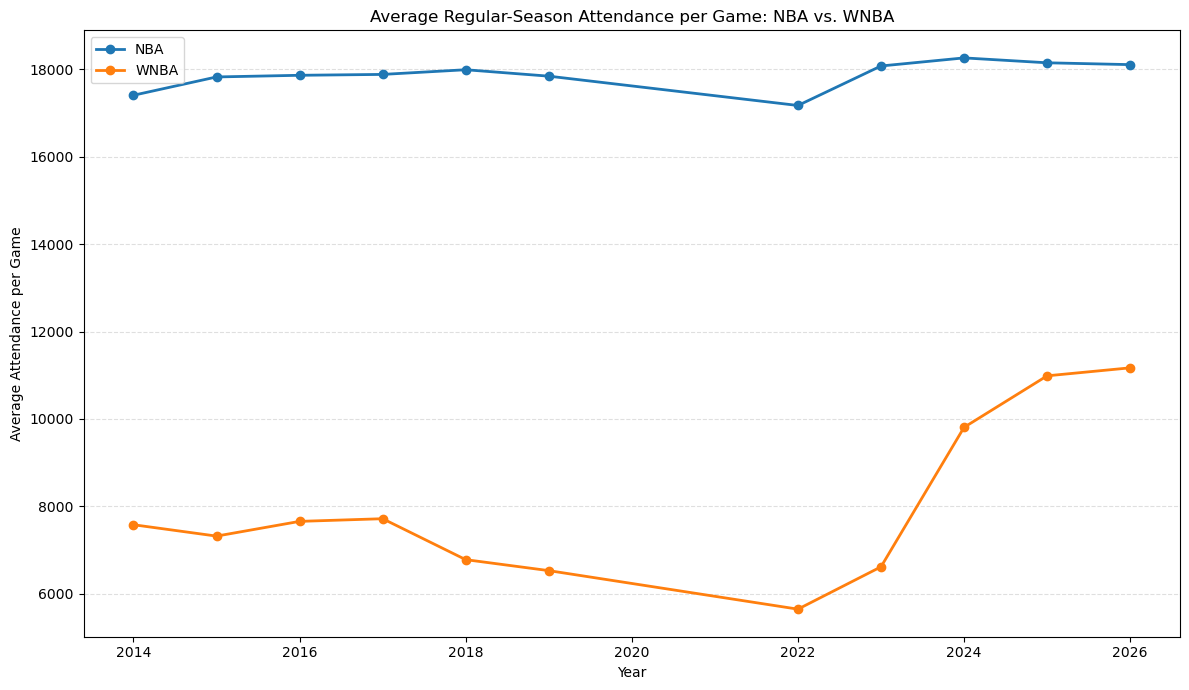

In [38]:
plt.figure(figsize=(12, 7))

plt.plot(
    attendance_comparison["Year"],
    attendance_comparison["NBA_Average_Attendance"],
    marker="o",
    linewidth=2,
    label="NBA"
)

plt.plot(
    attendance_comparison["Year"],
    attendance_comparison["WNBA_Average_Attendance"],
    marker="o",
    linewidth=2,
    label="WNBA"
)

plt.title("Average Regular-Season Attendance per Game: NBA vs. WNBA")
plt.xlabel("Year")
plt.ylabel("Average Attendance per Game")

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend()

plt.tight_layout()
plt.show()

In [39]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=attendance_comparison["Year"],
        y=attendance_comparison["NBA_Average_Attendance"],
        mode="lines+markers",
        name="NBA",
        hovertemplate=(
            "<b>NBA</b><br>"
            "Year: %{x}<br>"
            "Average attendance per game: %{y:,.0f}"
            "<extra></extra>"
        )
    )
)

fig.add_trace(
    go.Scatter(
        x=attendance_comparison["Year"],
        y=attendance_comparison["WNBA_Average_Attendance"],
        mode="lines+markers",
        name="WNBA",
        hovertemplate=(
            "<b>WNBA</b><br>"
            "Year: %{x}<br>"
            "Average attendance per game: %{y:,.0f}"
            "<extra></extra>"
        )
    )
)

fig.update_layout(
    title="Average Attendance per Game: NBA vs. WNBA",
    xaxis_title="Year",
    yaxis_title="Average Attendance per Game",
    hovermode="closest",
    template="plotly_white"
)

fig.update_yaxes(tickformat=",")
fig.show()

In [40]:
import plotly.graph_objects as go

# Sort by year so the final point is correct
attendance_comparison = attendance_comparison.sort_values("Year")

fig = go.Figure()

# NBA
fig.add_trace(
    go.Scatter(
        x=attendance_comparison["Year"],
        y=attendance_comparison["NBA_Average_Attendance"],
        mode="lines+markers",
        name="NBA",
        line=dict(
            color="#0072B2",
            width=3,
            dash="solid"
        ),
        marker=dict(
            symbol="circle",
            size=8
        ),
        hovertemplate=(
            "<b>NBA</b><br>"
            "Year: %{x}<br>"
            "Average attendance per game: %{y:,.0f}"
            "<extra></extra>"
        )
    )
)

# WNBA
fig.add_trace(
    go.Scatter(
        x=attendance_comparison["Year"],
        y=attendance_comparison["WNBA_Average_Attendance"],
        mode="lines+markers",
        name="WNBA",
        line=dict(
            color="#D55E00",
            width=3,
            dash="dash"
        ),
        marker=dict(
            symbol="square",
            size=8
        ),
        hovertemplate=(
            "<b>WNBA</b><br>"
            "Year: %{x}<br>"
            "Average attendance per game: %{y:,.0f}"
            "<extra></extra>"
        )
    )
)

# Get the final point of each line
last_year = attendance_comparison["Year"].iloc[-1]

last_nba = attendance_comparison[
    "NBA_Average_Attendance"
].iloc[-1]

last_wnba = attendance_comparison[
    "WNBA_Average_Attendance"
].iloc[-1]

# Put labels immediately next to the line endings
fig.add_annotation(
    x=last_year,
    y=last_nba,
    text="<b>NBA</b>",
    showarrow=False,
    xanchor="left",
    xshift=12,
    yshift=0,
    font=dict(
        size=15,
        color="#0072B2"
    )
)

fig.add_annotation(
    x=last_year,
    y=last_wnba,
    text="<b>WNBA</b>",
    showarrow=False,
    xanchor="left",
    xshift=12,
    yshift=0,
    font=dict(
        size=15,
        color="#D55E00"
    )
)

fig.update_layout(
    title="Average Regular-Season Attendance per Game: NBA vs. WNBA",
    xaxis_title="Year",
    yaxis_title="Average Attendance per Game",
    hovermode="closest",
    template="plotly_white",
    width=1100,
    height=650,

    # Hide the legend because the lines are labeled directly
    showlegend=False,

    # Create room for the labels after the final point
    margin=dict(r=100),

    font=dict(size=14)
)

# Extend the x-axis slightly so labels do not get cut off
fig.update_xaxes(
    range=[
        attendance_comparison["Year"].min(),
        attendance_comparison["Year"].max() + 1
    ],
    dtick=1
)

fig.update_yaxes(
    tickformat=",",
    gridcolor="lightgray"
)

fig.show()

In [41]:
fig.write_html(
    "nba_wnba_attendance.html",
    include_plotlyjs="cdn",
    full_html=True,
    config={
        "displayModeBar": True,
        "responsive": True,
        "displaylogo": False
    }
)

In [21]:
import pandas as pd
import requests
import re
from io import StringIO

# ---------------------------------------
# SETTINGS
# ---------------------------------------

START_YEAR = 2021
END_YEAR = 2026

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/149.0.0.0 Safari/537.36"
    )
}


# ---------------------------------------
# HELPER FUNCTION
# ---------------------------------------

def money_to_number(value):
    """
    Convert values such as '$1,507,100' into 1507100.
    Returns NaN when a value cannot be converted.
    """
    if pd.isna(value):
        return pd.NA

    value = str(value)

    # Remove dollar signs, commas, spaces, and other text
    value = re.sub(r"[^0-9.\-]", "", value)

    if value in ["", ".", "-"]:
        return pd.NA

    return pd.to_numeric(value, errors="coerce")


# ---------------------------------------
# SCRAPE EACH YEAR
# ---------------------------------------

cba_rows = []
all_team_tables = []

for year in range(START_YEAR, END_YEAR + 1):

    url = (
        "https://herhoopstats.com/"
        f"salary-cap-sheet/wnba/summary/{year}/"
    )

    print(f"Scraping {year}: {url}")

    response = requests.get(
        url,
        headers=HEADERS,
        timeout=30
    )

    response.raise_for_status()

    # Read every HTML table on the page
    tables = pd.read_html(StringIO(response.text))

    print(f"  Found {len(tables)} tables")

    # -----------------------------------
    # FIND CBA NUMBERS
    # -----------------------------------

    year_cba = {
        "Year": year,
        "Salary Cap": pd.NA,
        "Supermaximum Salary": pd.NA,
        "Maximum Salary": pd.NA,
        "Minimum Salary": pd.NA,
        "Source": url
    }

    for table in tables:

        # Convert the whole table to text for easier searching
        table_text = " ".join(
            table.astype(str)
                 .fillna("")
                 .values
                 .flatten()
        ).lower()

        if "salary cap" in table_text:

            # Flatten a two-column table
            if table.shape[1] >= 2:

                for _, row in table.iterrows():

                    label = str(row.iloc[0]).strip().lower()
                    value = row.iloc[1]

                    if label == "salary cap":
                        year_cba["Salary Cap"] = money_to_number(value)

                    elif "supermaximum" in label:
                        year_cba["Supermaximum Salary"] = money_to_number(value)

                    elif (
                        "player maximum" in label
                        and "supermaximum" not in label
                    ):
                        year_cba["Maximum Salary"] = money_to_number(value)

                    elif (
                        "player minimum" in label
                        and pd.isna(year_cba["Minimum Salary"])
                    ):
                        year_cba["Minimum Salary"] = money_to_number(value)

    cba_rows.append(year_cba)

    # -----------------------------------
    # FIND TEAM SALARY SUMMARY
    # -----------------------------------

    for table_number, table in enumerate(tables):

        table = table.copy()

        # Flatten multi-level column names if necessary
        if isinstance(table.columns, pd.MultiIndex):
            table.columns = [
                " ".join(
                    str(part)
                    for part in column
                    if str(part) != "nan"
                ).strip()
                for column in table.columns
            ]

        column_names = [
            str(column).lower()
            for column in table.columns
        ]

        has_team_column = any(
            "team" in column
            for column in column_names
        )

        has_salary_column = any(
            "salary" in column
            or "cap" in column
            or "payroll" in column
            for column in column_names
        )

        if has_team_column and has_salary_column:

            table["Year"] = year
            table["Source"] = url
            table["Table Number"] = table_number

            all_team_tables.append(table)

            print(
                f"  Possible team table found: "
                f"table {table_number}, shape={table.shape}"
            )


# ---------------------------------------
# CREATE CBA DATAFRAME
# ---------------------------------------

cba_salary = pd.DataFrame(cba_rows)

numeric_columns = [
    "Salary Cap",
    "Supermaximum Salary",
    "Maximum Salary",
    "Minimum Salary"
]

for column in numeric_columns:
    cba_salary[column] = pd.to_numeric(
        cba_salary[column],
        errors="coerce"
    )


# Identify the different agreement periods
cba_salary["CBA Period"] = cba_salary["Year"].apply(
    lambda year: "New 2026 CBA" if year >= 2026 else "2020 CBA"
)

print("\nCBA salary data:")
display(cba_salary)

Scraping 2021: https://herhoopstats.com/salary-cap-sheet/wnba/summary/2021/
  Found 2 tables
  Possible team table found: table 0, shape=(15, 8)
Scraping 2022: https://herhoopstats.com/salary-cap-sheet/wnba/summary/2022/
  Found 2 tables
  Possible team table found: table 0, shape=(15, 8)
Scraping 2023: https://herhoopstats.com/salary-cap-sheet/wnba/summary/2023/
  Found 2 tables
  Possible team table found: table 0, shape=(15, 8)
Scraping 2024: https://herhoopstats.com/salary-cap-sheet/wnba/summary/2024/
  Found 2 tables
  Possible team table found: table 0, shape=(15, 8)
Scraping 2025: https://herhoopstats.com/salary-cap-sheet/wnba/summary/2025/
  Found 2 tables
  Possible team table found: table 0, shape=(15, 8)
Scraping 2026: https://herhoopstats.com/salary-cap-sheet/wnba/summary/2026/
  Found 2 tables
  Possible team table found: table 0, shape=(15, 8)

CBA salary data:


,Year,Salary Cap,Supermaximum Salary,Maximum Salary,Minimum Salary,Source,CBA Period
0,2021,1339000,221450,190550,58710,https://herhoopstats.com/salary-cap-sheet/wnba...,2020 CBA
1,2022,1379200,228094,196267,60471,https://herhoopstats.com/salary-cap-sheet/wnba...,2020 CBA
2,2023,1420500,234936,202154,62285,https://herhoopstats.com/salary-cap-sheet/wnba...,2020 CBA
3,2024,1463200,241984,208219,64154,https://herhoopstats.com/salary-cap-sheet/wnba...,2020 CBA
4,2025,1507100,249244,214466,66079,https://herhoopstats.com/salary-cap-sheet/wnba...,2020 CBA
5,2026,7000000,1400000,1190000,270000,https://herhoopstats.com/salary-cap-sheet/wnba...,New 2026 CBA


In [22]:
cba_salary.to_csv(
    "wnba_cba_salary_data_2021_2026.csv",
    index=False
)

print("Saved: wnba_cba_salary_data_2021_2026.csv")

Saved: wnba_cba_salary_data_2021_2026.csv


In [23]:
from IPython.display import FileLink

FileLink("wnba_cba_salary_data_2021_2026.csv")

/Users/linda/Desktop/wnba/wnba_cba_salary_data_2021_2026.csv

In [24]:
if all_team_tables:

    team_salary_raw = pd.concat(
        all_team_tables,
        ignore_index=True,
        sort=False
    )

    team_salary_raw.to_csv(
        "wnba_team_salary_tables_2021_2026_raw.csv",
        index=False
    )

    print("Saved: wnba_team_salary_tables_2021_2026_raw.csv")
    display(team_salary_raw.head(20))

else:
    print("No team salary tables were identified.")

Saved: wnba_team_salary_tables_2021_2026_raw.csv


,Team,Total Salaries,Total Players,Cap Room,Guaranteed Salaries,Year,Source,Table Number
0,Atlanta Dream,"$1,339,000",13,$0,"$798,700",2021,https://herhoopstats.com/salary-cap-sheet/wnba...,0
1,Chicago Sky,"$1,338,778",11,$222,"$953,375",2021,https://herhoopstats.com/salary-cap-sheet/wnba...,0
2,Connecticut Sun,"$1,352,115",11,"-$13,115","$1,053,496",2021,https://herhoopstats.com/salary-cap-sheet/wnba...,0
3,Dallas Wings,"$1,243,559",12,"$95,441","$716,381",2021,https://herhoopstats.com/salary-cap-sheet/wnba...,0
4,Golden State Valkyries,$0,0,"$1,339,000",$0,2021,https://herhoopstats.com/salary-cap-sheet/wnba...,0
5,Indiana Fever,"$1,277,179",12,"$61,821","$645,991",2021,https://herhoopstats.com/salary-cap-sheet/wnba...,0
6,Las Vegas Aces,"$1,345,922",11,"-$6,922","$969,110",2021,https://herhoopstats.com/salary-cap-sheet/wnba...,0
7,Los Angeles Sparks,"$1,338,518",11,$482,"$882,643",2021,https://herhoopstats.com/salary-cap-sheet/wnba...,0
8,Minnesota Lynx,"$1,346,277",12,"-$7,277","$979,210",2021,https://herhoopstats.com/salary-cap-sheet/wnba...,0
9,New York Liberty,"$1,338,063",12,$937,"$855,907",2021,https://herhoopstats.com/salary-cap-sheet/wnba...,0


In [25]:
check_columns = [
    "Year",
    "Salary Cap",
    "Supermaximum Salary",
    "Maximum Salary",
    "Minimum Salary",
    "CBA Period"
]

display(cba_salary[check_columns])

,Year,Salary Cap,Supermaximum Salary,Maximum Salary,Minimum Salary,CBA Period
0,2021,1339000,221450,190550,58710,2020 CBA
1,2022,1379200,228094,196267,60471,2020 CBA
2,2023,1420500,234936,202154,62285,2020 CBA
3,2024,1463200,241984,208219,64154,2020 CBA
4,2025,1507100,249244,214466,66079,2020 CBA
5,2026,7000000,1400000,1190000,270000,New 2026 CBA


In [26]:
import pandas as pd

# Change this to your actual file location
attendance_file = (
    "/Users/linda/Desktop/WNBA/"
    "af22840c-69dd-4400-8d01-502370d15c7e"
)

attendance = pd.read_csv(attendance_file)

# Clean the columns
attendance["Year"] = pd.to_numeric(
    attendance["Year"],
    errors="coerce"
)

attendance["Attendance"] = pd.to_numeric(
    attendance["Attendance"]
        .astype(str)
        .str.replace(",", "", regex=False),
    errors="coerce"
)

attendance = attendance.dropna(
    subset=["Year", "Attendance"]
)

attendance["Year"] = attendance["Year"].astype(int)

In [27]:
audience_yearly = (
    attendance
    .groupby("Year", as_index=False)
    .agg(
        Total_Attendance=("Attendance", "sum"),
        Average_Attendance_Per_Game=("Attendance", "mean"),
        Games_Recorded=("Attendance", "count")
    )
)

display(audience_yearly)

,Year,Total_Attendance,Average_Attendance_Per_Game,Games_Recorded
0,1997,1126565,9796.217391,115
1,1998,1725018,10917.835443,158
2,1999,2118125,10382.965686,204
3,2000,2542056,9311.560440,273
4,2001,2554889,9290.505455,275
5,2002,2580352,9417.343066,274
6,2003,2294189,8892.205426,258
7,2004,2078363,8659.845833,240
8,2005,1957636,8190.945607,239
9,2006,1978146,7667.232558,258


In [28]:
comparison = pd.merge(
    cba_salary,
    audience_yearly,
    on="Year",
    how="inner"
)

comparison = comparison.sort_values("Year")

display(comparison)

,Year,Salary Cap,Supermaximum Salary,Maximum Salary,Minimum Salary,Source,CBA Period,Total_Attendance,Average_Attendance_Per_Game,Games_Recorded
0,2021,1339000,221450,190550,58710,https://herhoopstats.com/salary-cap-sheet/wnba...,2020 CBA,588280,3096.210526,190
1,2022,1379200,228094,196267,60471,https://herhoopstats.com/salary-cap-sheet/wnba...,2020 CBA,1433623,5973.429167,240
2,2023,1420500,234936,202154,62285,https://herhoopstats.com/salary-cap-sheet/wnba...,2020 CBA,1783892,6834.835249,261
3,2024,1463200,241984,208219,64154,https://herhoopstats.com/salary-cap-sheet/wnba...,2020 CBA,2632998,10011.399240,263
4,2025,1507100,249244,214466,66079,https://herhoopstats.com/salary-cap-sheet/wnba...,2020 CBA,3456848,11115.266881,311
5,2026,7000000,1400000,1190000,270000,https://herhoopstats.com/salary-cap-sheet/wnba...,New 2026 CBA,1451986,11169.123077,130


In [29]:
BASE_YEAR = 2021

base_salary = comparison.loc[
    comparison["Year"] == BASE_YEAR,
    "Salary Cap"
].iloc[0]

base_attendance = comparison.loc[
    comparison["Year"] == BASE_YEAR,
    "Average_Attendance_Per_Game"
].iloc[0]

comparison["Salary Cap Index"] = (
    comparison["Salary Cap"] / base_salary
) * 100

comparison["Audience Index"] = (
    comparison["Average_Attendance_Per_Game"]
    / base_attendance
) * 100

display(
    comparison[
        [
            "Year",
            "Salary Cap",
            "Average_Attendance_Per_Game",
            "Salary Cap Index",
            "Audience Index",
            "CBA Period"
        ]
    ]
)

,Year,Salary Cap,Average_Attendance_Per_Game,Salary Cap Index,Audience Index,CBA Period
0,2021,1339000,3096.210526,100.000000,100.000000,2020 CBA
1,2022,1379200,5973.429167,103.002240,192.927100,2020 CBA
2,2023,1420500,6834.835249,106.086632,220.748402,2020 CBA
3,2024,1463200,10011.399240,109.275579,323.343621,2020 CBA
4,2025,1507100,11115.266881,112.554145,358.995837,2020 CBA
5,2026,7000000,11169.123077,522.778193,360.735260,New 2026 CBA


In [30]:
import plotly.graph_objects as go

fig = go.Figure()

# Salary-cap growth line
fig.add_trace(
    go.Scatter(
        x=comparison["Year"],
        y=comparison["Salary Cap Index"],
        mode="lines+markers",
        name="Salary cap growth",
        line=dict(
            color="#0072B2",
            width=4,
            dash="solid"
        ),
        marker=dict(
            size=9,
            symbol="circle"
        ),
        customdata=comparison[["Salary Cap"]],
        hovertemplate=(
            "<b>Year:</b> %{x}<br>"
            "<b>Salary index:</b> %{y:.1f}<br>"
            "<b>Salary cap:</b> $%{customdata[0]:,.0f}"
            "<extra></extra>"
        )
    )
)

# Attendance growth line
fig.add_trace(
    go.Scatter(
        x=comparison["Year"],
        y=comparison["Audience Index"],
        mode="lines+markers",
        name="Audience growth",
        line=dict(
            color="#D55E00",
            width=4,
            dash="dash"
        ),
        marker=dict(
            size=9,
            symbol="square"
        ),
        customdata=comparison[
            ["Average_Attendance_Per_Game"]
        ],
        hovertemplate=(
            "<b>Year:</b> %{x}<br>"
            "<b>Audience index:</b> %{y:.1f}<br>"
            "<b>Average attendance:</b> "
            "%{customdata[0]:,.0f} per game"
            "<extra></extra>"
        )
    )
)

# Vertical line marking the new agreement
fig.add_vline(
    x=2026,
    line_width=2,
    line_dash="dot",
    line_color="gray"
)

fig.add_annotation(
    x=2026,
    y=comparison["Salary Cap Index"].max(),
    text="2026: New CBA",
    showarrow=True,
    arrowhead=2,
    ax=-75,
    ay=-40
)

fig.update_layout(
    title={
        "text": (
            "WNBA Salary-Cap Growth Versus "
            "Average Attendance Growth"
        ),
        "x": 0.5
    },
    xaxis_title="Year",
    yaxis_title="Growth index (2021 = 100)",
    hovermode="x unified",
    template="plotly_white",
    width=1000,
    height=650,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="center",
        x=0.5
    )
)

fig.update_xaxes(
    tickmode="linear",
    dtick=1
)

fig.show()